# **Grupo 2: Frozen Lake para comparativa de modelos tabulares**

Autor:

- Miguel Ángel Ortiz Peñaranda


## Introducción

El objetivo de este notebook es establecer una comparativa en cuanto a desempeño para distintos agentes de aprendizaje por refuerzo que siguen el modelo **tabular**. El modelo tabular almacena una tabla Q(s, a), donde se indica, para cada posible estado de un problema y cada posible acción a realizar, el valor esperado del retorno (recompensa) de la misma. De esta forma, durante la interacción con el entorno como los que nos encontramos en _gymnasium_, el agente es entrenado para elegir la acción más ventajosa dependiendo del estado en el que se encuentre, siguiendo una política determinada.

Los modelos tabulares presentan una serie de ventajas claras:

- Son sencillos de implementar y de comprender, tanto a nivel de funcionamiento como a nivel de resultados.
- Existen garantías de que los modelos acaben convergiendo hacia una política óptima.
- Para entornos discretos presentan un buen desempeño si son configurados correctamente. Su entrenamiento es también por lo general bastante rápido, pues acceder a cada celda es inmediato.

Sin embargo, traen consigo también una serie de desventajas inherentes a su funcionamiento:
- Al almacenar una matriz bidimensional por cada par estado-acción, tenemos que esta tabla crece desproporcionadamente cuando el número de estados o acciones posibles es grande. Esto puede acabar suponiendo un problema de memoria cuando la tabla es significativa.
- Estos agentes funcionan bien para conjuntos de estados y acciones discretos, pero son incapaces de resolver problemas cuyos conjuntos sean continuos, pues son valores para los que no es posible confeccionar una tabla.
- No son capaces de generalizar. Aprenden el valor para un estado concreto, pero no tienen la capacidad de extrapolar ese aprendizaje a estados que sean similares.

## Descripción del entorno

En este notebook en particular, nos centraremos en el problema de _gymnasium_ **Frozen Lake**, que trata de cruzar un mapa de celdas, desde un origen hasta una posición objetivo, intentando no caer en uno de los agujeros que existen en el lago. Si se llega a la celda objetivo, la recompensa será de 1. En caso contrario (caer por un agujero), o ir a cualquier otra posición, la recompensa será de 0. Caer por un agujero o llegar al objetivo supone que se complete ese episodio.

El tamaño del mapa permite ser configurado a 4x4 posiciones o 8x8 posiciones, lo que implica un **espacio discreto de 16 o 64 estados posibles**, respectivamente. El espacio de acciones queda comprendido por **4 acciones**, que se corresponden con el movimiento hacia arriba, abajo, izquierda y derecha.

Si bien el entorno permite ser configurado para que sea resbaladizo, lo que implica que, con cierta probabilidad, el jugador puede acabar en una casilla que no es la deseada, hemos desactivado esta característica para simplificar el comportamiento del entorno.

## Metodología de trabajo

Se propone una metodología de trabajo en la que se va a probar, tanto con distintas variantes del entorno, como con distintas variantes de los agentes tabulares, el desempeño para cada agente. Siendo así, seguiremos los siguientes pasos:

1. Para cada entorno, entrenaremos todos los tipos de agentes tabulares comprendidos.
2. Se obtendrán una serie de estadísticas que nos permitan graficar la recompensa obtenida por cada agente a lo largo del tiempo, y la evolución de la longitud de cada episodio, en _steps_.
3. Se comparará la mejor recompensa obtenida por el agente con el resto de agentes, y la mejor longitud de episodio que es capaz de conseguir con la del resto de agentes y con la óptima.
4. Se pomediarán los resultados obtenidos para cada entorno, para cada agente.
5. Se darán unas conclusiones finales que indiquen qué algoritmo o algoritmos se considera que presentan un mejor comportamiento.

## 1. Preparación del Entorno

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "FrozenLake"**:
Se cargan dos versiones del entorno "FrozenLake": una de 4x4 y otra de 8x8. Ambas versiones no son resbaladizas, lo que facilita la comprensión de los resultados, dado que el entorno resbaladizo podría dificultar la comprensión inicial del aprendizaje.

- **Importación de las implementaciones de los agentes**:
Se importarán las implementaciones existentes bajo src/ de los agentes tabulares que deseamos comparar
  - Monte Carlo On Policy
  - Monte Carlo Off Policy
  - SARSA
  - QLearning


Dependencias adicionales para poder ser ejecutado en colab.

In [27]:
!pip install 'gym[box2d]==0.20.0'

## Instalación de paquetes adicionales para uso en colab
!apt-get update
!apt install swig
!pip install gymnasium[box2d]

Se utiliza este código para clonar el repositorio y fijar en path de cara a poder ejecutarlo en colab.

In [ ]:
!rm -r exml-ortizpenaranda/
!git clone https://github.com/miguelangelortizpenaranda/exml-ortizpenaranda.git
!cd exml-ortizpenaranda/

In [1]:
#@title Importamos todas las clases y funciones
import sys


# Añadir los directorios fuentes al path de Python
sys.path.append('/content/exml-ortizpenaranda/entornos_complejos/src/eml_complex_environments')
sys.path.append('src/eml_complex_environments')

# Verificar que se han añadido correctamente
print(sys.path)

#!ls

['/Users/miguelangel/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/jupyter_debug', '/Users/miguelangel/Applications/PyCharm.app/Contents/plugins/python-ce/helpers/pydev', '/Users/miguelangel/PycharmProjects/exml-ortizpenaranda', '/Users/miguelangel/PycharmProjects/exml-ortizpenaranda/k_brazos/src/eml_k_bandit', '/Users/miguelangel/PycharmProjects/exml-ortizpenaranda/entornos_complejos/src/eml_complex_environments', '/Users/miguelangel/PycharmProjects/exml-ortizpenaranda/entornos_complejos/src/eml_complex_environments/agents', '/Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip', '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13', '/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload', '', '/Users/miguelangel/PycharmProjects/exml-ortizpenaranda/.venv/lib/python3.13/site-packages', '/content/exml-ortizpenaranda/entornos_complejos/src/eml_complex_environments', 'src/eml_complex_environments']


In [2]:
from tqdm import tqdm
import gymnasium as gym

from agents import *
from util import *

A continuación vamos a crear dos instancias del entorno de Frozen Lake, una con 4 celdas de alto y ancho, y otra con 8. Al ser en esta última el mapa más grande, presenta por tanto mayor complejidad para ser resuelto por parte del agente.

Como hemos comentado, fijamos el parámetro `is_slippery=False` para asegurarnos que los movimientos son deterministas, y no se aplica esa probabilidad de "deslizarse" a una casilla contigua.

In [29]:
name = 'FrozenLake-v1'
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi")
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi")

Establecemos también una semilla aleatoria y se la fijamos a _numpy_, de forma que, cuando intentemos obtener algún número aleatorio, obtengamos los mismos de forma consistente
entre distintas ejecuciones del programa, en distintos equipos.

In [30]:
random_seed = 123
np.random.seed(random_seed)

## 2. Diseño de los agentes y algoritmo de entrenamiento

Cada agente queda representado por una clase distinta, que implementa el algoritmo que sigue para realizar el proceso de aprendizaje y la toma de decisiones. Todos los agentes
heredan de la clase abstracta **TabularAgent**, que presenta los siguientes métodos:

- `get_action`: En base al estado actual en el que se encuentre el agente, toma una acción usando una política. La política que vamos a utilizar cuando el agente está aprendiendo es una política epsilon-greedy, que permite que se "explote" la mejor acción conocida la mayoría del tiempo, pero permite "explorar" nuevas acciones con una probabilidad determinada. Esta política se deriva de una epsilon-soft, donde varias acciones pueden tener una probabilidad determinada de ser elegidas. Si establecemos que se utilice epsilon-decay, esta probabilidad de explorar irá decreciendo conforme nos acerquemos al final del entrenamiento del agente. Cuando el agente haya sido entrenado, utilizaremos una política puramente greedy, que elegirá siempre la mejor acción conocida para cada estado.
- `on_episode_step`: Este método será llamado para cada agente cuando se realice un cambio de estado en un episodio (el agente realice una acción). Como, en base a esa acción, obtenemos una recompensa y un nuevo estado, podemos usar esos valores para que cada agente actualice su estado interno. Los agentes como los que usan diferencias temporales actualizarán su tabla interna en este método, mientras que las variantes de Monte Carlo lo harán al terminar el episodio.
- `on_episode_finished`: Se llamará a este método cuando el agente haya finalizado un episodio, ya sea porque ha llegado al objetivo o porque ha terminado abruptamente (se ha caído por un agujero, por ejemplo). Cada agente realizará las acciones pertinentes en este caso. Por ejemplo, Monte Carlo iterará por todos los pasos dados para actualizar su tabla.


El siguiente método `run_agent` recibe como parámetro la clase genérica de tipo `Agent`, de forma que sea agnóstico a la implementación del agente que se va a entrenar. Realizará las siguientes acciones:

- Iterará por un número especificado de episodios en el entorno especificado, en cada cual el agente intentará resolver el problema y llegar al objetivo.
- Para cada episodio puede darse el caso de que se termine de forma natural (porque llega al objetivo, o ha caído por un agujero en el hielo), o que haya sido truncado, porque exista un número máximo de pasos, o _steps_, configurados para ese episodio, de forma que el agente no pueda quedarse de forma infinita estancado en el mismo.
- Se calcularán durante el transcurso del entrenamiento las estadísticas de promedio de recompensas acumuladas por episodio, y longitud de cada episodio, de cara a graficar el comportamiento de cada agente

In [31]:

def run_agent(agent, env, num_episodes=5000):
  """
  Entrena al agente especificado, en un entorno concreto, a lo largo de un número de episodios. Obtiene algunas métricas
  que se utilizarán posteriormente para graficar el comportamiento del agente.
  :param agent: Agente que se va a entrenar
  :param env: Entorno de gymnasium en el que se va a entrenar el agente
  :param num_episodes: Número de episodios en los que se va a comprender el entrenamiento
  :return: tabla Q del agente, lista de recompensas acumuladas, lista de longitud de cada episodio, número de episodios completados correctamente, y promedio de longitud de episodio correcto
  """
  # Para mostrar la evolución en el terminal y algún dato que mostrar
  stats = 0.0
  list_stats = [stats]
  step_display = num_episodes / 10
  lengths = 0.0
  episode_lengths = [lengths]
  n_correct_finished_episodes = 0
  sum_correct_episode_lengths = 0
  avg_correct_episode_length = 0.0

  for t in tqdm(range(num_episodes)):
      current_state, info = env.reset(seed=random_seed)
      agent.set_initial_state(current_state)
      done = False
      while not done:
          action = agent.get_action(current_state)
          new_state, reward, episode_finished, truncated, info = env.step(action)
          done = episode_finished or truncated
          agent.on_episode_step(new_state, action, reward, t, episode_finished)
          current_state = new_state
          if episode_finished and reward == 1:
            n_correct_finished_episodes += 1
            sum_correct_episode_lengths += agent.get_episode_len()

      episode_lengths.append(agent.get_episode_len())
      result_sum = agent.on_episode_finished()

      # Guardamos datos sobre la evolución. Promedio de recompensas
      stats += result_sum
      avg_stat = stats/(t+1)
      list_stats.append(avg_stat)

      current_epsilon = agent.get_current_epsilon()
      # Para mostrar la evolución.  Comentar si no se quiere mostrar
      if t % step_display == 0 and t != 0:
          print(f"success: {stats/t}, epsilon: {current_epsilon}")

  if n_correct_finished_episodes > 0:
    avg_correct_episode_length = sum_correct_episode_lengths / n_correct_finished_episodes

  return agent.get_q_table(), list_stats, episode_lengths, n_correct_finished_episodes, avg_correct_episode_length


Definimos también el método `run_agents` que nos permite hacer lo propio pero para un conjunto de agentes. En un diccionario se almacenará, usando como clave el nombre de cada agente:
- La Q table de ese agente tras su entrenamiento
- La proporción de recompensas para ese agente
- La longitud de cada episodio para ese agente
- El número total de episodios completados correctamente (llegando a la casilla objetivo) por ese agente
- El promedio de la longitud de los episodios terminados correctamente, en _steps_

In [32]:
def run_agents(agents, env, num_episodes):
    """
    Entrena un conjunto de agentes en un entorno determinado, obteniendo métricas de su desempeño para almacenarlas y más tarde
    devolverlas cuando termine el entrenamiento del conjunto
    :param agents: Conjunto de agentes a entrenar
    :param env: entorno en el que se entrenarán los agentes
    :param num_episodes: número de episodios para los cuales se realizará el entrenamiento
    :return: tabla Q de los agentes, listas de recompensas acumuladas, listas de longitudes de cada episodio, número de episodios completados correctamente, y promedio de longitud de episodio correcto
    """
    agent_q_tables = {}
    agent_stats = {}
    agent_episode_lengths = {}
    agent_correct_finished_episodes = {}
    agent_avg_correct_episode_lengths = {}

    for agent in agents:
        agent_name = agent.get_name()
        print(f'\nRunning agent {agent_name}')
        q_table, list_stats, episode_lengths, n_correct_finished_episodes, avg_correct_episode_length = run_agent(agent, env, num_episodes)
        agent_q_tables[agent_name] = q_table
        agent_stats[agent_name] = list_stats
        agent_episode_lengths[agent_name] = episode_lengths
        agent_correct_finished_episodes[agent_name] = n_correct_finished_episodes
        agent_avg_correct_episode_lengths[agent_name] = avg_correct_episode_length

    return agent_q_tables, agent_stats, agent_episode_lengths, agent_correct_finished_episodes, agent_avg_correct_episode_lengths

Se define asimismo un método de apoyo, `create_agents`, que nos permita crear todos los agentes que se van a evaluar parametrizados

In [33]:
def create_agents(env, epsilon, discount_factor, epsilon_decay):
    """
    Crea todos los agentes tabulares para los que se va a realizar el entrenamiento y comparativa. Admite los parámetros con los que se va a probar
    en la experimentación.
    :param env: Entorno sobre el que se va a entrenar a los agentes
    :param epsilon: Factor que determina cómo de exploratorio es el agente
    :param discount_factor: Factor de descuento para el retorno futuro (1.0 = no se realiza descuento sobre valor futuro)
    :param epsilon_decay: Indica si el factor epsilon va decreciendo
    :return: array con todos los agentes parametrizados
    """
    monte_carlo_on_policy = MonteCarloOnPolicy(environment=env, epsilon=epsilon, discount_factor=discount_factor, random_seed=random_seed, epsilon_decay=epsilon_decay)
    monte_carlo_off_policy = MonteCarloOffPolicy(environment=env, epsilon=epsilon, discount_factor=discount_factor, random_seed=random_seed, epsilon_decay=epsilon_decay)
    sarsa = SARSA(environment=env, epsilon=epsilon, discount_factor=discount_factor, learning_rate=0.1, random_seed=random_seed, epsilon_decay=epsilon_decay)
    qlearning = QLearning(environment=env, epsilon=epsilon, discount_factor=discount_factor, learning_rate=0.1, random_seed=random_seed, epsilon_decay=epsilon_decay)
    return [monte_carlo_on_policy, monte_carlo_off_policy, sarsa, qlearning]

## 3. Ejecución del experimento

En esta sección se va a proceder, dado el algoritmo y los agentes implementados previamente, a evaluar su desempeño en dos variantes del entorno Frozen Lake:

- Entorno 4x4, con un total de 16 casillas
- Entorno 8x8, con un total de 64 casillas

Si bien la librería _gymnasium_ permite definir un entorno al usuario, hemos decidido utilizar los que genera la propia librería por simplicidad.
Para cada variante del entorno, vamos a probar todos los agentes con las siguientes variaciones en sus parámetros:

- **epsilon** = [0.4, 0.5, 0.6]
- **discount_factor** = [1, 0.9]
- **epsilon_decay** = [True, False]

De esta forma podemos observar cómo se comportan los agentes con distintas componentes exploratorias, así como para distintos factores de descuento para el retorno
futuro que se obtiene de la tabla Q(s, a). El uso de epsilon decaimiento supondrá que el algoritmo se volverá más greedy y menos exploratorio por cierto conforme
el agente va llegando a los últimos episodios, es decir, explotará únicamente la política aprendida y apenas no explorará, en contraste con al principio del algoritmo,
que actuará de forma prácticamente aleatoria.

Se visualizará para la comparativa:
- Proporción máxima de recompensas que ha obtenido el agente
- Número total de episodios que han terminado correctamente
- Promedio de longitud de los episodios que han terminado correctamente

Al final de la experimentación promediaremos estos valores para ver que agente ha conseguido, de forma general, obtener mejores resultados.

Graficaremos también:

- La evolución de la proporción de recompensas (nos dirá el porcentaje de veces que el agente ha llegado al estado terminal)
- La longitud de los episodios para poder visualizar de qué forma y a qué ritmo aprenden los agentes a desenvolverse por el entorno.

Para apoyar a la visualización de los resultados, es posible que se muestre los valores de Q para cada par estado-acción, de forma que se vea, para cada estado, como valora el agente cada acción. Mostraremos también la política óptima del mismo.


Todos los métodos usados para esta impresión y visualización se pueden localizar en el paquete `src/util` de la práctica.

### 3.1 Experimentación en el escenario 4x4

Procedemos a la experimentación para la variante de entorno de 4x4, con 16 casillas posibles para el mapa. Recordemos que caer en cualquier casilla supondrá una recompensa de 0, excepto para el objetivo, cuya recompensa es de 1. El mapa por defecto para el escenario de 4x4 es, según la documentación, el siguiente:

```
"4x4":[
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG"
]
```

El camino óptimo hacia el objetivo, con la configuración por defecto, es de 6 pasos.

Se entrenará a los agentes a lo largo de **50000 episodios**, y veremos las métricas que obtiene cada uno para realizar una comparativa entre los mismos. Vamos a realizar una búsqueda de hiperparámetros para intentar determinar, no solo qué agentes se comportan mejor, sino qué parámetros son los más deseables de entre los contemplados para dirigir su entrenamiento.



In [34]:
num_episodes = 50000

En primer lugar, vamos a utilizar un grid search entre valores para epsilon fijos y valores para el factor de descuento para ver qué algoritmo se comporta mejor. Definimos la función `run_experiment_using_grid_search` de forma a aportar algo de genericidad a la experimentación. Solo hemos de pasar el entorno y el grid de parámetros deseado y la propia función ya obtiene todas las estadísticas, para todos los agentes, para todas las combinaciones de parámetros que se le den.


In [35]:
import itertools

def run_experiment_using_grid_search(env, param_grid):
    """
    Entrena una serie de agentes y obtiene distintas métricas utilizando un grid de parámetros
    Se realizarán tantos entrenamientos como posibles combinaciones de parámetros existan en el grid
    :param env: entorno sobre el que se realizará el entrenamiento
    :param param_grid: grid de parámetros con los que se realizarán los entrenamientos
    :return: tabla Q de los agentes, listas de recompensas acumuladas, listas de longitudes de cada episodio, número de episodios completados correctamente, y promedio de longitud de episodio correcto,
    para cada una de las combinaciones de parámetros
    """
    results_q_tables = {}
    results_stats = {}
    results_episode_lengths = {}
    results_correct_finished_episodes = {}
    results_avg_correct_episode_lengths = {}

    # Itera por el grid de parámetros, realizando todas las combinatorias
    for epsilon, discount_factor, epsilon_decay in itertools.product(param_grid["epsilon"], parameters["discount_factor"], parameters["epsilon_decay"]):

        print(f'\nParameter values: epsilon: {epsilon}, discount_factor: {discount_factor}\n')

        agents = create_agents(env, epsilon, discount_factor, epsilon_decay) # Crea los distintos agentes

        # Ejecuta el experimento para todos los agentes, con estos parámetros en particular
        agent_q_tables, agent_stats, agent_episode_lengths, agent_correct_finished_episodes, agent_avg_correct_episode_lengths = run_agents(agents, env, num_episodes=num_episodes)

        key = (epsilon, discount_factor)
        results_q_tables[key] = agent_q_tables
        results_stats[key] = agent_stats
        results_episode_lengths[key] = agent_episode_lengths
        results_correct_finished_episodes[key] = agent_correct_finished_episodes
        results_avg_correct_episode_lengths[key] = agent_avg_correct_episode_lengths

    return results_q_tables, results_stats, results_episode_lengths, results_correct_finished_episodes, results_avg_correct_episode_lengths

Definimos el grid de parámetros y ejecutamos el experimento con los agentes definidos previamente. Se muestra información durante el entrenamiento de los agentes, como la proporción de recompensas y epsilon, que recordemos en estos casos se mantendrá fijo puesto que no utilizamos epsilon decay.

In [36]:

parameters = {
    'epsilon': [0.3, 0.4, 0.5],
    'discount_factor': [1.0, 0.9],
    'epsilon_decay': [False]
}

results_q_tables, results_stats, results_episode_lengths, results_correct_finished_episodes, results_avg_correct_episode_lengths = run_experiment_using_grid_search(env4, parameters)



Parameter values: epsilon: 0.3, discount_factor: 1.0


Running agent MonteCarloOnPolicy


 11%|█▏        | 5743/50000 [00:00<00:06, 7099.35it/s]

success: 0.6512, epsilon: 0.3


 23%|██▎       | 11460/50000 [00:01<00:05, 7376.19it/s]

success: 0.6498, epsilon: 0.3


...

 82%|████████▏ | 41218/50000 [00:06<00:01, 6905.22it/s]

success: 0.40425, epsilon: 0.5


 93%|█████████▎| 46306/50000 [00:07<00:00, 6055.05it/s]

success: 0.40584444444444445, epsilon: 0.5


100%|██████████| 50000/50000 [00:08<00:00, 6168.89it/s]


Mostramos las estadísticas obtenidas para cada combinación de parámetros, para cada agente. En estas estadísticas podemos observar a simple vista lo siguiente:

- Monte Carlo On-Policy, SARSA y Q-Learning parecen mostrar un desempeño similar si nos fijamos en el número de episodios completados, la máxima proporción de la recompensa y la longitud media de episodios completados, en general para todas las combinaciones de parámetros.
- Monte Carlo Off-Policy parece que tiene un rendimiento peor al resto, y parece presentar más dificultades para aprender la política, dándonos una proporción de recompensas inferior a los demás agentes, y una longitud de los episodios muy por encima a los demás.
- En general un valor de epsilon comedido, de 0.3, y la utilización de un factor de descuento de 0.9 parecen ser los parámetros que mejores resultados dan.

In [37]:
for epsilon, discount_factor in itertools.product(parameters["epsilon"], parameters["discount_factor"]):
    print(f'\nParameter values: epsilon: {epsilon}, discount_factor: {discount_factor}\n')
    key = (epsilon, discount_factor)
    print_max_reward_proportion_for_agents(results_stats[key])
    print('\n')
    print_max_correctly_finished_episodes_for_agents(results_correct_finished_episodes[key])
    print('\n')
    print_correct_finished_episodes_length_avg_for_agents(results_avg_correct_episode_lengths[key])



Parameter values: epsilon: 0.3, discount_factor: 1.0

[MonteCarloOnPolicy] Máxima proporcion recompensa: 0.6514
[MonteCarloOffPolicy] Máxima proporcion recompensa: 0.36296
[SARSA] Máxima proporcion recompensa: 0.62314
[QLearning] Máxima proporcion recompensa: 0.6481


[MonteCarloOnPolicy] Episodios terminados correctamente: 32570
[MonteCarloOffPolicy] Episodios terminados correctamente: 18148
[SARSA] Episodios terminados correctamente: 31157
[QLearning] Episodios terminados correctamente: 32405


[MonteCarloOnPolicy] Promedio de longitud por episodio completado correctamente: 8.113018114829599
[MonteCarloOffPolicy] Promedio de longitud por episodio completado correctamente: 13.578796561604584
[SARSA] Promedio de longitud por episodio completado correctamente: 10.12010142183137
[QLearning] Promedio de longitud por episodio completado correctamente: 7.976392532016664

Parameter values: epsilon: 0.3, discount_factor: 0.9

[MonteCarloOnPolicy] Máxima proporcion recompensa: 0.66082
[MonteC

Mostramos también, para todos los resultados obtenidos anteriormente, cuáles son los mejores en términos absolutos, en cuanto a mayor número de episodios completados y longitud promedio de los episodios.

En línea con lo observado, Monte Carlo On-Policy ha resultado ser el que mejor se ha comportado, con 33041 episodios completados correctamente de 50000, y una longitud promedio de esos episodios de 7.83.

In [38]:
print_global_best_for_finished_episodes(results_correct_finished_episodes)
print_global_best_for_episodes_length_avg(results_avg_correct_episode_lengths)

El agente que mayor número de episodios ha terminado ha sido: MonteCarloOnPolicy con 33041 episodios para los parámetros (0.3, 0.9)
El agente que mas rápido ha completado los episodios ha sido: MonteCarloOnPolicy con 7.832813776822736 pasos en promedio para los parámetros (0.3, 0.9)


Mostramos también las gráficas para el caso que mejor desempeño nos dio anteriormente. En este caso, con epsilon = 0.3 y discount_factor = 0.9. Vemos como, en general, todos los agentes aprenden a llegar al objetivo a lo largo de los episodios (aumenta la proporción de recompensa) hasta sobrepasar 0.6 en todos los casos. Esto implica también más de la mitad de episodios completados correctamente en este caso.


La longitud de los episodios se muestra variable, pero normalmente se sitúa entre 6.4 pasos a 7.2 pasos, lo cual se acerca bastante a la longitud óptima.


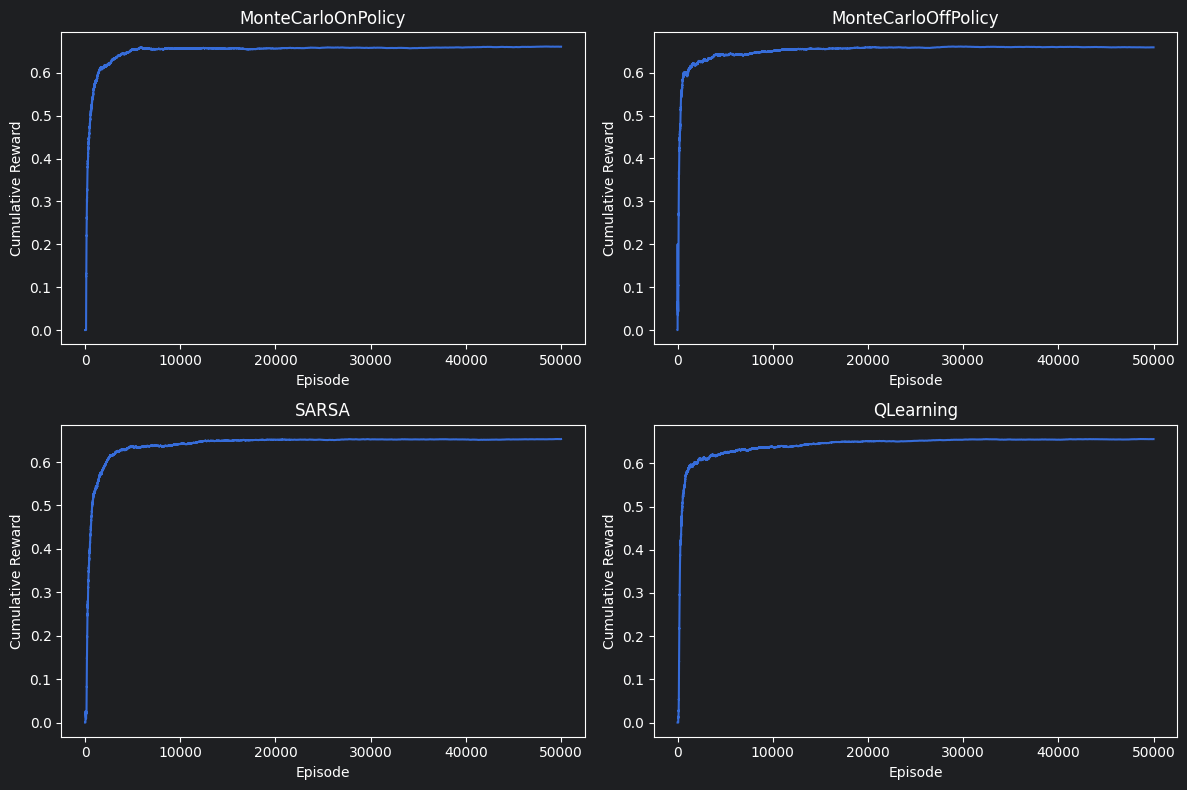

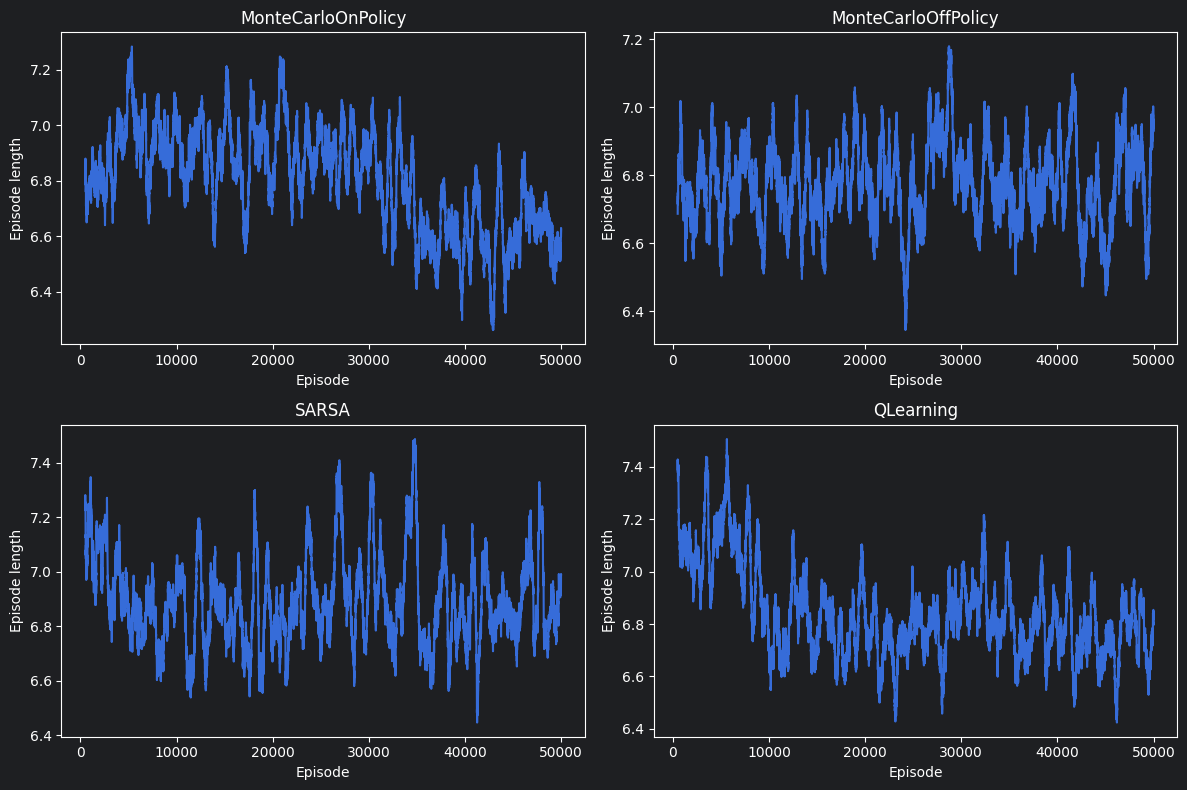

In [39]:
key = (0.3, 0.9)
plot_agent_rewards(results_stats[key])
plot_episode_lengths_for_agents(results_episode_lengths[key])

Procedemos a ejecutar el experimento utilizando **Epsilon Decay**. Como ya no tenemos valores fijos de epsilon, podemos permitirnos dejar este parámetro en el grid con valor a 1.0, pues no se utilizará. La relación que se utilizará para calcular el epsilon será en base a una constante que hemos llamado `decay_factor`, cuyo valor situaremos inicialmente a 1000 (queremos poder modificarlo para controlar como de rápido decrece epsilon):

$\epsilon = decay\_factor / (t + 1)$

Siendo $t$ el número de episodio en el que se encuentra el agente en ese instante.

De esta forma, el agente presentará un comportamiento casi totalmente aleatorio al principio y, conforme avancen los episodios, irá tornándose más greedy, explotando las mejores acciones conocidas en lugar de explorar otras nuevas.

Podemos ver durante el entrenamiento como el valor de epsilon va decayendo conforme pasa el tiempo.

In [40]:

parameters = {
    'epsilon': [1.0],
    'discount_factor': [1.0, 0.9],
    'epsilon_decay': [True]
}

results_q_tables, results_stats, results_episode_lengths, results_correct_finished_episodes, results_avg_correct_episode_lengths = run_experiment_using_grid_search(env4, parameters)



Parameter values: epsilon: 1.0, discount_factor: 1.0


Running agent MonteCarloOnPolicy


 13%|█▎        | 6574/50000 [00:00<00:05, 7905.91it/s]

success: 0.4488, epsilon: 0.19996000799840033


 23%|██▎       | 11553/50000 [00:01<00:04, 8200.96it/s]

success: 0.6499, epsilon: 0.0999900009999


...

 83%|████████▎ | 41488/50000 [00:05<00:01, 7492.86it/s]

success: 0.874775, epsilon: 0.02499937501562461


 93%|█████████▎| 46604/50000 [00:06<00:00, 7188.62it/s]

success: 0.8860222222222223, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:07<00:00, 6989.51it/s]


Mostramos las estadísticas obtenidas para cada combinación de parámetros, para cada agente.

A simple vista podemos ver como los resultados son significativamente mejores que con un valor de epsilon fijo, debido a que cuando un agente aprende una política óptima no tiene la necesidad de seguir explorando de forma tan acentuada. Ahora, incluso Monte Carlo Off-Policy parece comportarse igual de bien que el resto de algoritmos, a diferencia de lo visto en el apartado anterior.

Vemos un número superior de episodios completados correctamente, así como una proporción mayor de recompensa, y un número menor de longitud de pasos por episodio completado que en el caso anterior.

Volvemos a observar una vez mas que usar un factor de descuento moderado resulta ser beneficioso en general para todos los agentes.


In [41]:
for epsilon, discount_factor in itertools.product(parameters["epsilon"], parameters["discount_factor"]):
    print(f'\nParameter values: discount_factor: {discount_factor}\n')
    key = (epsilon, discount_factor)
    print_max_reward_proportion_for_agents(results_stats[key])
    print('\n')
    print_max_correctly_finished_episodes_for_agents(results_correct_finished_episodes[key])
    print('\n')
    print_correct_finished_episodes_length_avg_for_agents(results_avg_correct_episode_lengths[key])


Parameter values: discount_factor: 1.0

[MonteCarloOnPolicy] Máxima proporcion recompensa: 0.89692
[MonteCarloOffPolicy] Máxima proporcion recompensa: 0.045
[SARSA] Máxima proporcion recompensa: 0.83296
[QLearning] Máxima proporcion recompensa: 0.89588


[MonteCarloOnPolicy] Episodios terminados correctamente: 44846
[MonteCarloOffPolicy] Episodios terminados correctamente: 2250
[SARSA] Episodios terminados correctamente: 41648
[QLearning] Episodios terminados correctamente: 44794


[MonteCarloOnPolicy] Promedio de longitud por episodio completado correctamente: 6.328056013914284
[MonteCarloOffPolicy] Promedio de longitud por episodio completado correctamente: 14.595555555555556
[SARSA] Promedio de longitud por episodio completado correctamente: 7.708053207837111
[QLearning] Promedio de longitud por episodio completado correctamente: 6.396816537929187

Parameter values: discount_factor: 0.9

[MonteCarloOnPolicy] Máxima proporcion recompensa: 0.89676
[MonteCarloOffPolicy] Máxima proporc

Mostramos los mejores resultados de esta ejecución.

En cuanto a episodios completados parece ganar SARSA con 44865 episodios totales completados de 50000, con un factor de descuento del 0.9.

El menor número de pasos lo ha conseguido Monte Carlo On-Policy con 6.32 pasos, muy cerca del camino óptimo, también utilizando un factor de descuento de 0.9.

In [42]:
print_global_best_for_finished_episodes(results_correct_finished_episodes)
print_global_best_for_episodes_length_avg(results_avg_correct_episode_lengths)

El agente que mayor número de episodios ha terminado ha sido: SARSA con 44865 episodios para los parámetros (1.0, 0.9)
El agente que mas rápido ha completado los episodios ha sido: MonteCarloOnPolicy con 6.327846915562692 pasos en promedio para los parámetros (1.0, 0.9)


Mostramos también las gráficas para el caso que mejor desempeño nos dio anteriormente. En este caso, con discount_factor = 0.9.

Vemos como en general todos los agentes aprenden bastante rápido si nos fijamos en las gráficas de la proporción de retorno acumulado. Algunos agentes muestran un pico al principio que parece indicar que por pura aleatoriedad llegaron a soluciones buenas. Vemos también como parece que Monte Carlo Off-Policy tarda más en aprender la política que el resto, mostrando una curva ligeramente más suave.

Si vemos las gráficas de longitud por episodio (que se muestran con una media deslizante para favorecer la visibilidad), vemos que Monte Carlo On-Policy, SARSA y Q-Learning van reduciendo poco a poco la longitud de los episodios que juegan. Monte Carlo Off-Policy parece que una vez que aprende la política objetivo correcta, termina todos los episodios correctamente y en un tiempo razonable. En general, todos muestran el comportamiento esperado.


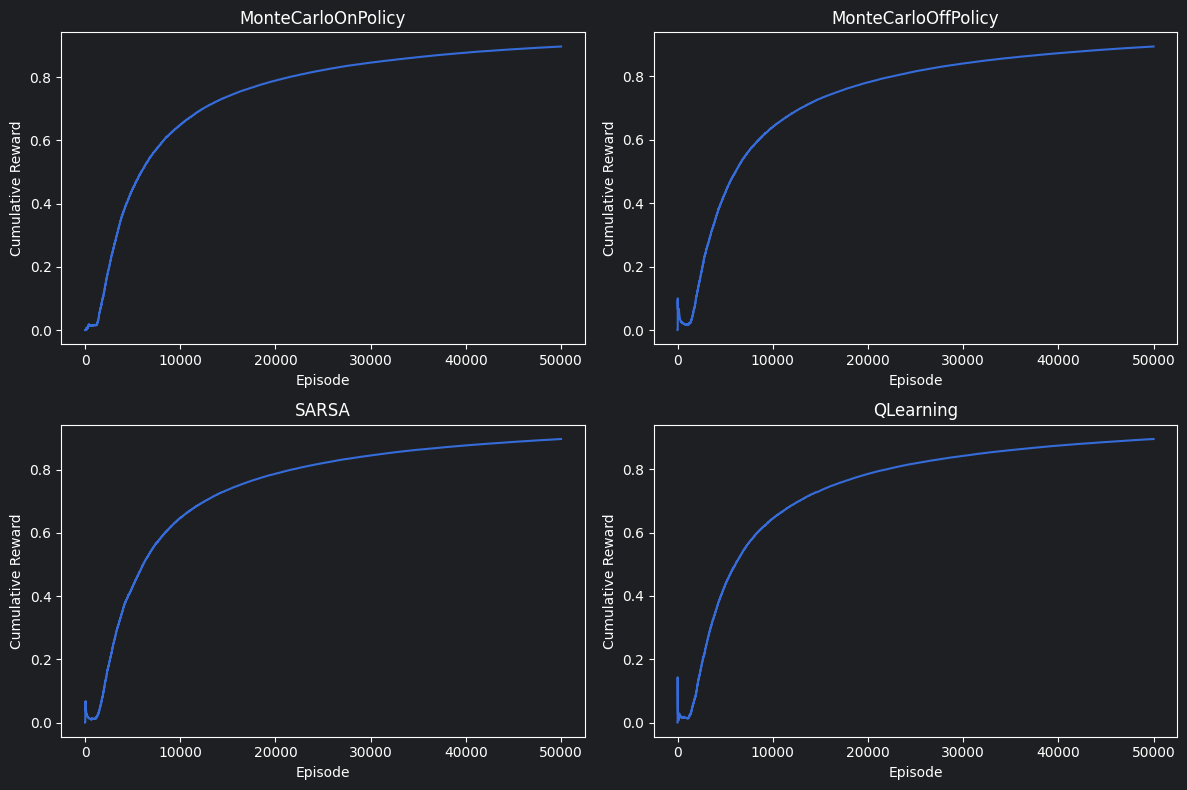

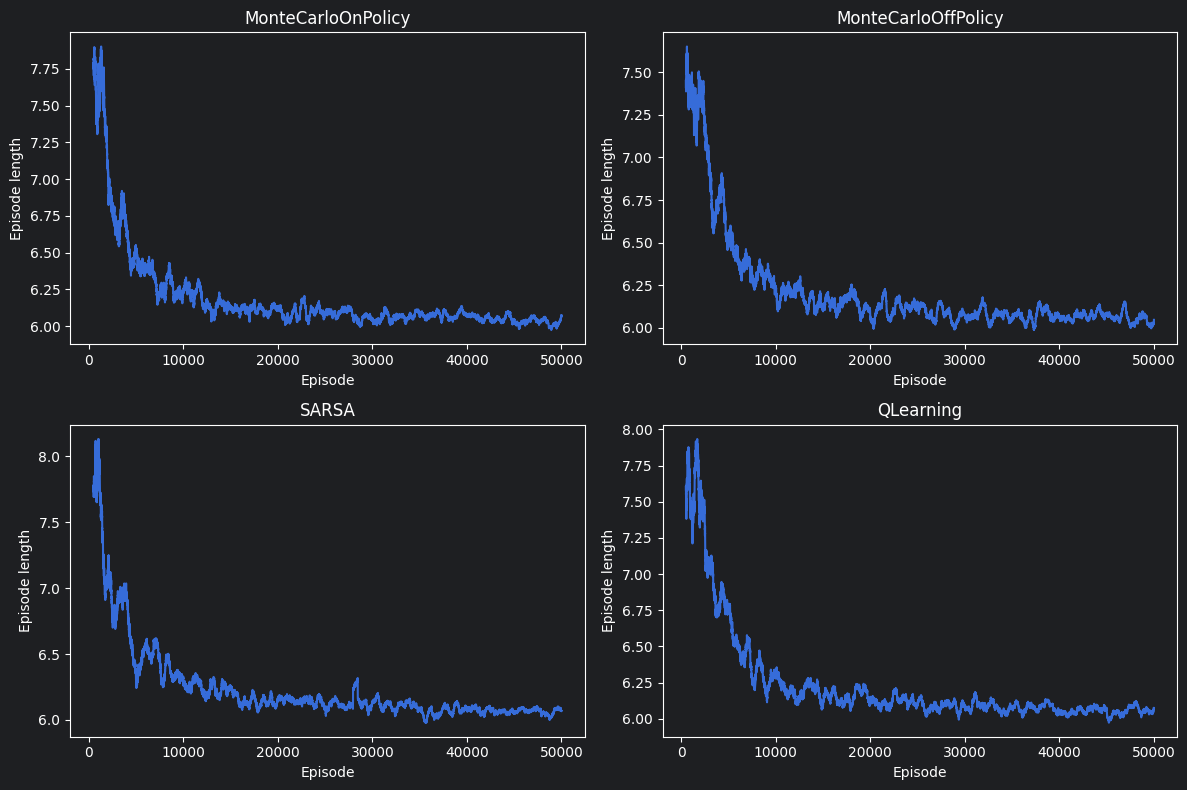

In [43]:
key = (1.0, 0.9)
plot_agent_rewards(results_stats[key])
plot_episode_lengths_for_agents(results_episode_lengths[key])

Vamos a mostrar la tabla Q que ha construído MonteCarlo On-Policy, que ha conseguido buenos resultados, para comprobar que los valores de retorno esperado logren definir el camino óptimo.

Recodemos que las acciones eran: `LEFT, DOWN, RIGHT, UP = 0,1,2,3`. Si nos fijamos en cada fila (estado) de la tabla, vemos que las acciones que mayor retorno ofrecen son siempre aquellas que llevan al objetivo, por ejemplo, empezando desde arriba a la izquierda [0,0]:
```
[0,0] --> acción 1 (abajo)
[1,0] --> acción 1 (abajo)
[2,0] --> acción 2 (derecha)
...
Hasta llegar al objetivo
```


In [44]:
key = (1.0, 0.9)
monte_carlo_on_policy_q = results_q_tables[key]['MonteCarloOnPolicy']
print(monte_carlo_on_policy_q)

[[0.18418484 0.51915876 0.20422309 0.1899034 ]
 [0.03267682 0.         0.33520495 0.03839605]
 [0.05589699 0.47487172 0.09349406 0.11498085]
 [0.17234025 0.         0.02694975 0.02523076]
 [0.29963644 0.59999981 0.         0.27556495]
 [0.         0.         0.         0.        ]
 [0.         0.69973483 0.         0.25699417]
 [0.         0.         0.         0.        ]
 [0.43337465 0.         0.68677881 0.37073777]
 [0.48193748 0.6869364  0.78235102 0.        ]
 [0.60676145 0.89055699 0.         0.5765458 ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.45801169 0.8600994  0.39326272]
 [0.71944472 0.84772786 1.         0.71893539]
 [0.         0.         0.         0.        ]]


Imprimimos también la tabla de la política objetivo (pi estrella), en base a la tabla Q y al entorno. Se puede ver como la política se configura en sintonía con la tabla Q que hemos mostrado. Para cada estado, se contempla una única acción a realizar.


In [45]:
print_pi_star_from_q(env4, monte_carlo_on_policy_q)

Política óptima obtenida
 [[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones 1, 1, 2, 2, 1, 2,  
 Para el siguiente grid
   (Right)
SFFF
FHFH
FFFH
HFFG



### 3.2 Experimentación en el escenario 8x8

Ahora vamos a utilizar la variante del escenario de 8x8, con 64 casillas posibles en las que puede moverse el agente. Las condiciones son las mismas que en el apartado anterior, si bien al haber incrementado el tamaño del escenario (y por tanto, el número de posibles estados, agujeros, y una mayor distancia a la casilla objetivo), también se incrementa la complejidad del problema. El mapa por defecto para el escenario de 8x8 es, según la documentación, el siguiente:

```
"8x8": [
    "SFFFFFFF",
    "FFFFFFFF",
    "FFFHFFFF",
    "FFFFFHFF",
    "FFFHFFFF",
    "FHHFFFHF",
    "FHFFHFHF",
    "FFFHFFFG",
]
```

El camino óptimo hacia el objetivo tiene, en este caso, **14 pasos**.

Se vuelve a realizar la experimentación utilizando **50000 episodios**, y el mismo grid de parámetros que se definió anteriormente, pero ahora pasando `env8` al método que realiza el entrenamiento.


In [46]:
parameters = {
    'epsilon': [0.3, 0.4, 0.5],
    'discount_factor': [1.0, 0.9],
    'epsilon_decay': [False]
}

results_q_tables, results_stats, results_episode_lengths, results_correct_finished_episodes, results_avg_correct_episode_lengths = run_experiment_using_grid_search(env8, parameters)


Parameter values: epsilon: 0.3, discount_factor: 1.0


Running agent MonteCarloOnPolicy


 10%|█         | 5247/50000 [00:03<00:27, 1654.97it/s]

success: 0.5694, epsilon: 0.3


 21%|██        | 10524/50000 [00:06<00:22, 1757.28it/s]

success: 0.6264, epsilon: 0.3


...

 81%|████████  | 40260/50000 [00:15<00:03, 2520.22it/s]

success: 0.25795, epsilon: 0.5


 91%|█████████ | 45441/50000 [00:17<00:01, 2629.46it/s]

success: 0.25424444444444444, epsilon: 0.5


100%|██████████| 50000/50000 [00:19<00:00, 2577.82it/s]


Si usamos valores de epsilon fijos, tenemos unos resultados bastante poco deseables por lo general. Se nota como la dificultad añadida de este mapa más grande interfiere en el aprendizaje de la política. Por lo general, si bien todos los agentes han conseguido resolver el problema, hay algunos, como SARSA, o MonteCarlo Off-Policy, que han llegado a resolverlo solo 2000 y 7000 episodios respectivamente, de un total de 50000 episodios. También podemos ver como su máxima proporción de recompensa generalmente se sitúa por debajo de 0.5. Cuanto más baja, menos episodios ha logrado resolver el agente. Podemos ver en estos dos tipos de agentes valores de incluso 0.04 en el caso de MonteCarlo Off-Policy, o 0.15 en SARSA para epsilon=0.4, y que esto sucede con independencia de los parámetros elegidos. Quizá un número significativamente mayor de episodios hubiera mejorado estos resultados.

Vemos también que el tamaño promedio de los episodios completados suele distar bastante del número de pasos en el camino óptimo, lo que indica que los agentes dan "palos de ciego" hasta llegar al objetivo, toman muchos pasos para evitar los agujeros en lugar de ir directamente al mismo. Al encontrarnos con un epsilon fijo, esto es esperable, pues, aunque haya encontrado una política buena, el agente no deja de explorar acciones aleatorias y esto puede conllevar el fracaso en un episodio.

In [47]:
for epsilon, discount_factor in itertools.product(parameters["epsilon"], parameters["discount_factor"]):
    print(f'\nParameter values: epsilon: {epsilon}, discount_factor: {discount_factor}\n')
    key = (epsilon, discount_factor)
    print_max_reward_proportion_for_agents(results_stats[key])
    print('\n')
    print_max_correctly_finished_episodes_for_agents(results_correct_finished_episodes[key])
    print('\n')
    print_correct_finished_episodes_length_avg_for_agents(results_avg_correct_episode_lengths[key])


Parameter values: epsilon: 0.3, discount_factor: 1.0

[MonteCarloOnPolicy] Máxima proporcion recompensa: 0.74734
[MonteCarloOffPolicy] Máxima proporcion recompensa: 0.28892
[SARSA] Máxima proporcion recompensa: 0.10084
[QLearning] Máxima proporcion recompensa: 0.59968


[MonteCarloOnPolicy] Episodios terminados correctamente: 37367
[MonteCarloOffPolicy] Episodios terminados correctamente: 14446
[SARSA] Episodios terminados correctamente: 5042
[QLearning] Episodios terminados correctamente: 29984


[MonteCarloOnPolicy] Promedio de longitud por episodio completado correctamente: 23.859367891455026
[MonteCarloOffPolicy] Promedio de longitud por episodio completado correctamente: 39.43762979371452
[SARSA] Promedio de longitud por episodio completado correctamente: 28.52181673938913
[QLearning] Promedio de longitud por episodio completado correctamente: 20.04815901814301

Parameter values: epsilon: 0.3, discount_factor: 0.9

[MonteCarloOnPolicy] Máxima proporcion recompensa: 0.6897
[MonteC

Imprimimos los resultados globales que identifican que agentes se han comportado mejor. Sorprendentemente, SARSA, aunque ha presentado bastante pobres para epsilon=0.4 y sin factor de descuento (1.0), para un epsilon de 0.3 y un factor de descuento de 0.9 ha logrado completar el mayor número de episodios de todos los agentes, con 37907.

Q-Learning ha sido el agente que más rápido ha completado los episodios, para los mismos parámetros que SARSA, con 19.56 pasos de media.

In [48]:
print_global_best_for_finished_episodes(results_correct_finished_episodes)
print_global_best_for_episodes_length_avg(results_avg_correct_episode_lengths)

El agente que mayor número de episodios ha terminado ha sido: SARSA con 37907 episodios para los parámetros (0.3, 0.9)
El agente que mas rápido ha completado los episodios ha sido: QLearning con 19.556417331642926 pasos en promedio para los parámetros (0.3, 0.9)


Por último, mostramos las gráficas de la proporción de recompensas, y vemos como, si bien los agentes han realizado un aprendizaje de la política, algunos consiguen estabilizarse antes que otros. Destacamos Monte Carlo Off-Policy, que vimos como presentaba peores resultados anteriormente. Vemos aquí esto reflejado, con una curva de proporción de recompensas que tarda más en llegar a su pináculo. Algo curioso que vemos en QLearning es que la proporción de recompensas baja, es decir, esto puede significar que cuando llegó a cierto punto empezó a errar en el mapa, probablemente por haber mantenido el epsilon fijo.

Si nos fijamos en las gráficas de promedio de longitud de los episodios, vemos como todos tienen longitudes bastante dispares pero altas, sobre todo al principio, comprendidas entre los 30 y los 18 pasos. Es interesante ver como Monte Carlo Off-Policy tiene una longitud de episodios significativa hasta que logra aprender la política objetivo óptima, donde el tamaño de episodio baja significativamente. Vemos que todos, en general, si bien se sitúan por encima del camino óptimo en pasos, no están muy alejados.

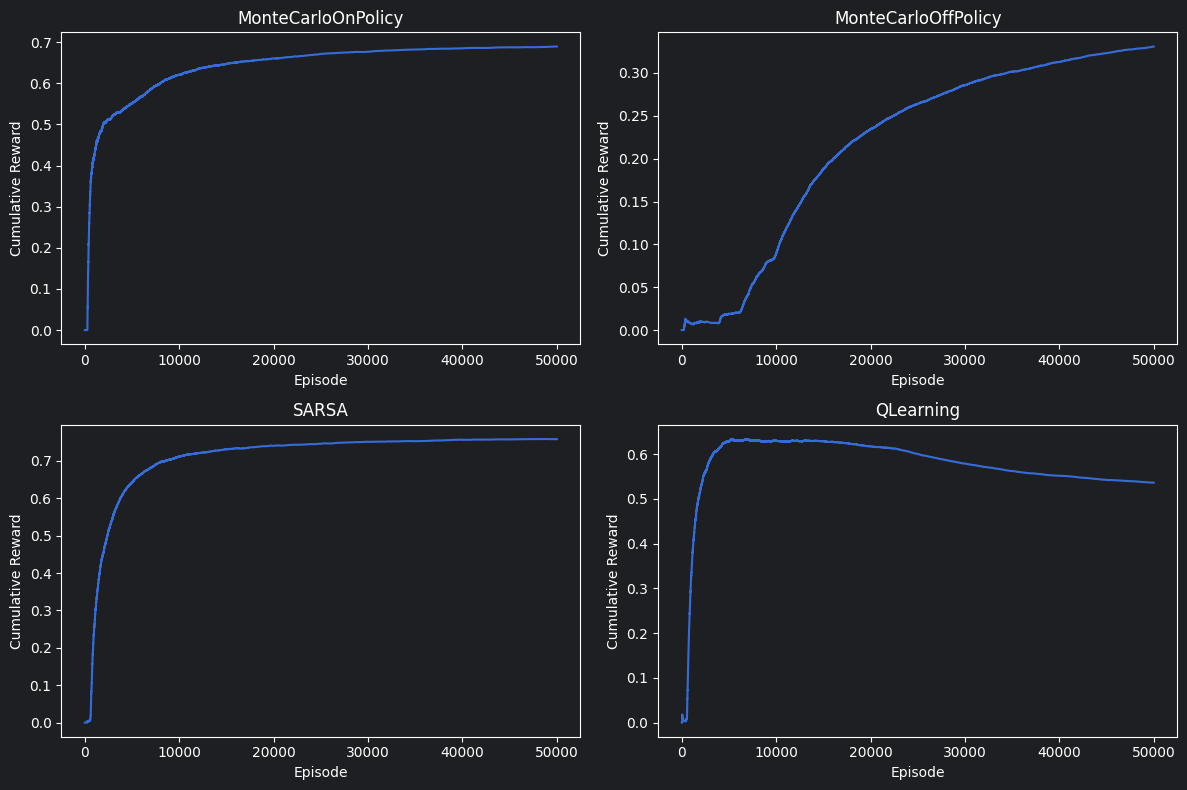

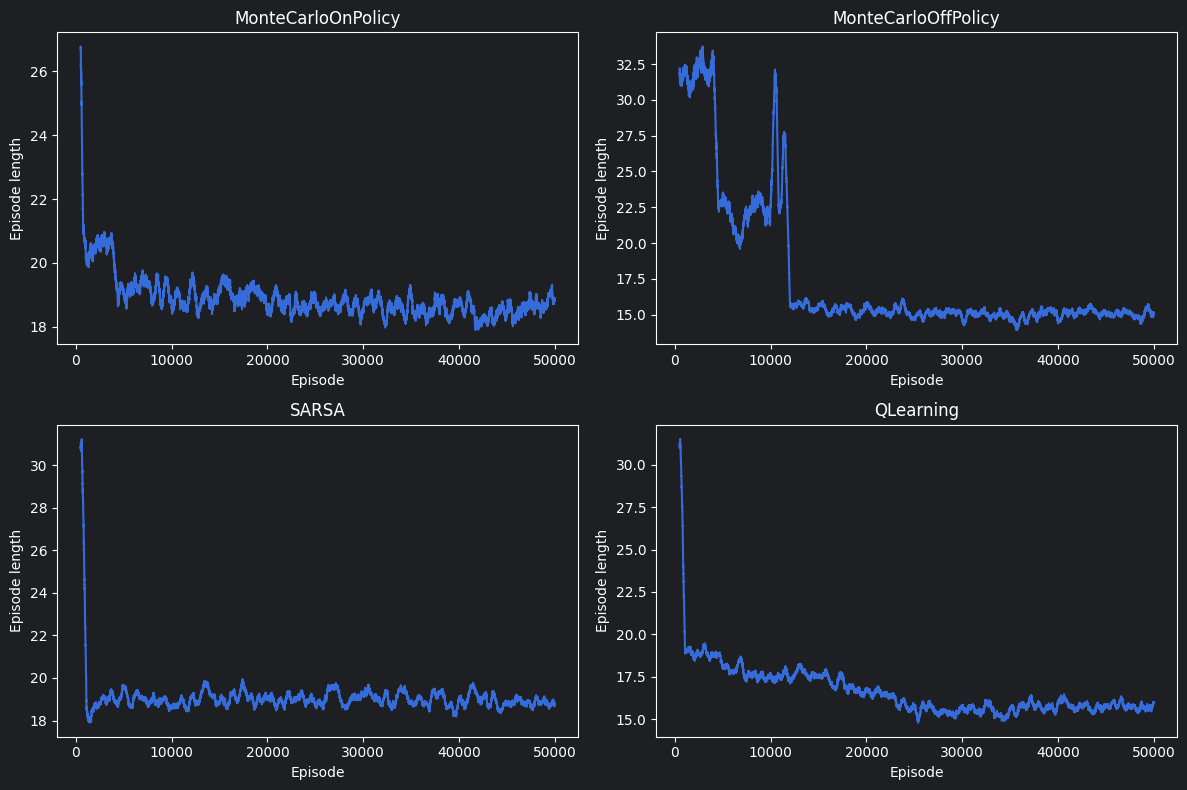

In [49]:
key = (0.3, 0.9)
plot_agent_rewards(results_stats[key])
plot_episode_lengths_for_agents(results_episode_lengths[key])

A continuación se realizará la ejecución utilizando epsilon decaimiento, donde el valor de la constante exploratoria se va reduciendo a lo largo de los episodios.

Vemos en la ejecución como el valor de epsilon se va reduciendo, utilizando la relación que ya se citó anteriormente.

In [50]:
parameters = {
    'epsilon': [1.0],
    'discount_factor': [1.0, 0.9],
    'epsilon_decay': [True]
}

results_q_tables, results_stats, results_episode_lengths, results_correct_finished_episodes, results_avg_correct_episode_lengths = run_experiment_using_grid_search(env8, parameters)


Parameter values: epsilon: 1.0, discount_factor: 1.0


Running agent MonteCarloOnPolicy


 10%|█         | 5230/50000 [00:03<00:35, 1277.79it/s]

success: 0.4946, epsilon: 0.19996000799840033


 21%|██        | 10360/50000 [00:05<00:12, 3182.25it/s]

success: 0.7002, epsilon: 0.0999900009999


...

 81%|████████  | 40426/50000 [00:13<00:03, 3103.35it/s]

success: 0.87365, epsilon: 0.02499937501562461


 91%|█████████▏| 45639/50000 [00:15<00:01, 3160.32it/s]

success: 0.885, epsilon: 0.02222172840603542


100%|██████████| 50000/50000 [00:16<00:00, 2965.58it/s]


En este caso, vemos como los agentes han dado mucho mejores resultados que en el caso anterior pues, una vez aprenden la política óptima, dejan de explorar y se encargan solo de seguir las acciones que les dicta esta última.

Monte Carlo Off-Policy ahora presenta mejores resultados también que en el caso anterior, junto con SARSA, que logran completar un número mayor de episodios exitosamente.

In [51]:
for epsilon, discount_factor in itertools.product(parameters["epsilon"], parameters["discount_factor"]):
    print(f'\nParameter values: discount_factor: {discount_factor}\n')
    key = (epsilon, discount_factor)
    print_max_reward_proportion_for_agents(results_stats[key])
    print('\n')
    print_max_correctly_finished_episodes_for_agents(results_correct_finished_episodes[key])
    print('\n')
    print_correct_finished_episodes_length_avg_for_agents(results_avg_correct_episode_lengths[key])


Parameter values: discount_factor: 1.0

[MonteCarloOnPolicy] Máxima proporcion recompensa: 0.9224
[MonteCarloOffPolicy] Máxima proporcion recompensa: 0.21574
[SARSA] Máxima proporcion recompensa: 0.03378
[QLearning] Máxima proporcion recompensa: 0.89962


[MonteCarloOnPolicy] Episodios terminados correctamente: 46120
[MonteCarloOffPolicy] Episodios terminados correctamente: 10787
[SARSA] Episodios terminados correctamente: 1689
[QLearning] Episodios terminados correctamente: 44981


[MonteCarloOnPolicy] Promedio de longitud por episodio completado correctamente: 17.054336513443193
[MonteCarloOffPolicy] Promedio de longitud por episodio completado correctamente: 63.263001761379435
[SARSA] Promedio de longitud por episodio completado correctamente: 25.864416814683246
[QLearning] Promedio de longitud por episodio completado correctamente: 15.199484226673484

Parameter values: discount_factor: 0.9

[MonteCarloOnPolicy] Máxima proporcion recompensa: 0.8834
[MonteCarloOffPolicy] Máxima prop

Imprimimos los resultados globales y vemos como el agente que mayor número de episodios ha completado satisfactoriamente ha sido Monte Carlo On-Policy, con 46120 episodios (casi todos los del entrenamiento) con un factor de descuento de 1.0.

SARSA ha conseguido la mínima longitud por episodio con 14.98 pasos, que se acerca mucho a la longitud del camino óptimo que dicta esta configuración del entorno.

In [52]:
print_global_best_for_finished_episodes(results_correct_finished_episodes)
print_global_best_for_episodes_length_avg(results_avg_correct_episode_lengths)

El agente que mayor número de episodios ha terminado ha sido: MonteCarloOnPolicy con 46120 episodios para los parámetros (1.0, 1.0)
El agente que mas rápido ha completado los episodios ha sido: SARSA con 14.982970116142504 pasos en promedio para los parámetros (1.0, 0.9)


Vemos en las gráficas como todos van incrementando su proporción de recompensas hasta acercarse e incluso sobrepasar al 0.8 (un 80% de los episodios completados satisfactoriamente). También podemos observar como, conforme van aprendiendo, va disminuyendo la longitud por episodio. Sobre todo en Monte-Carlo Off-Policy esta curva queda bastante suavizada, pues un epsilon decreciente acaba introduciendo menos "ruido" a la política aprendida.

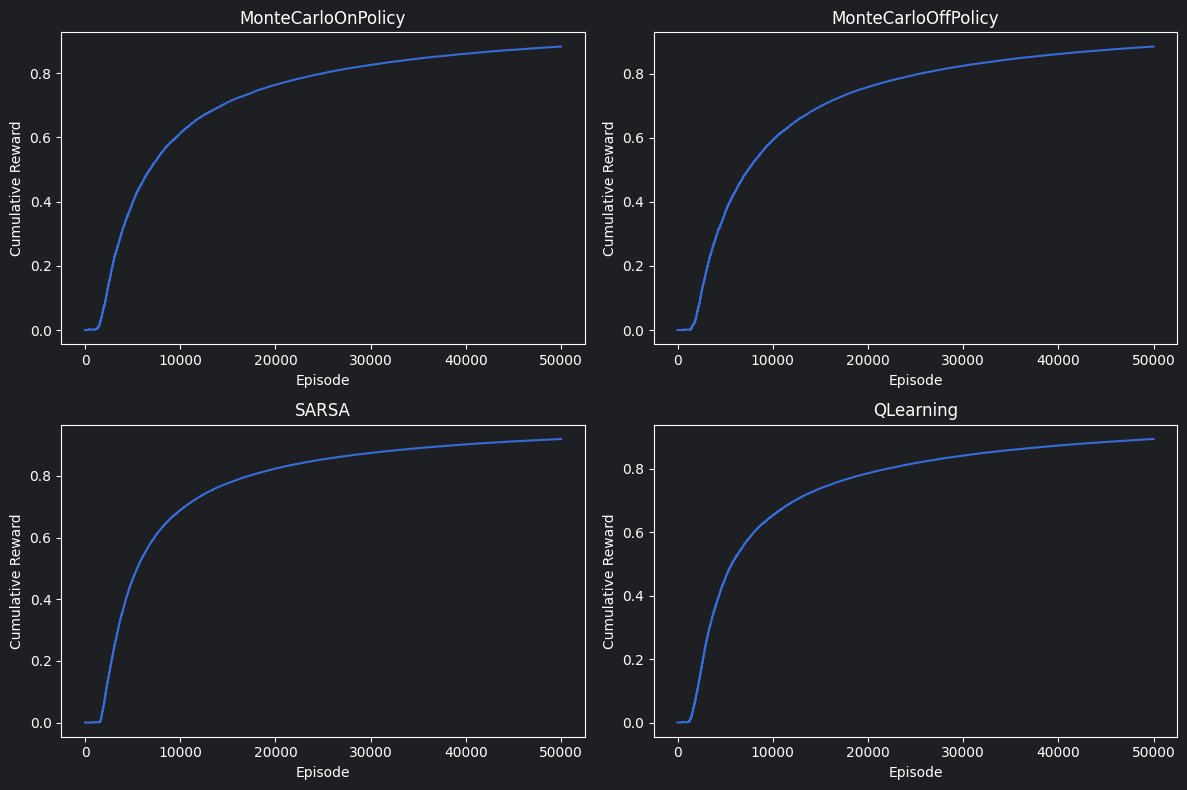

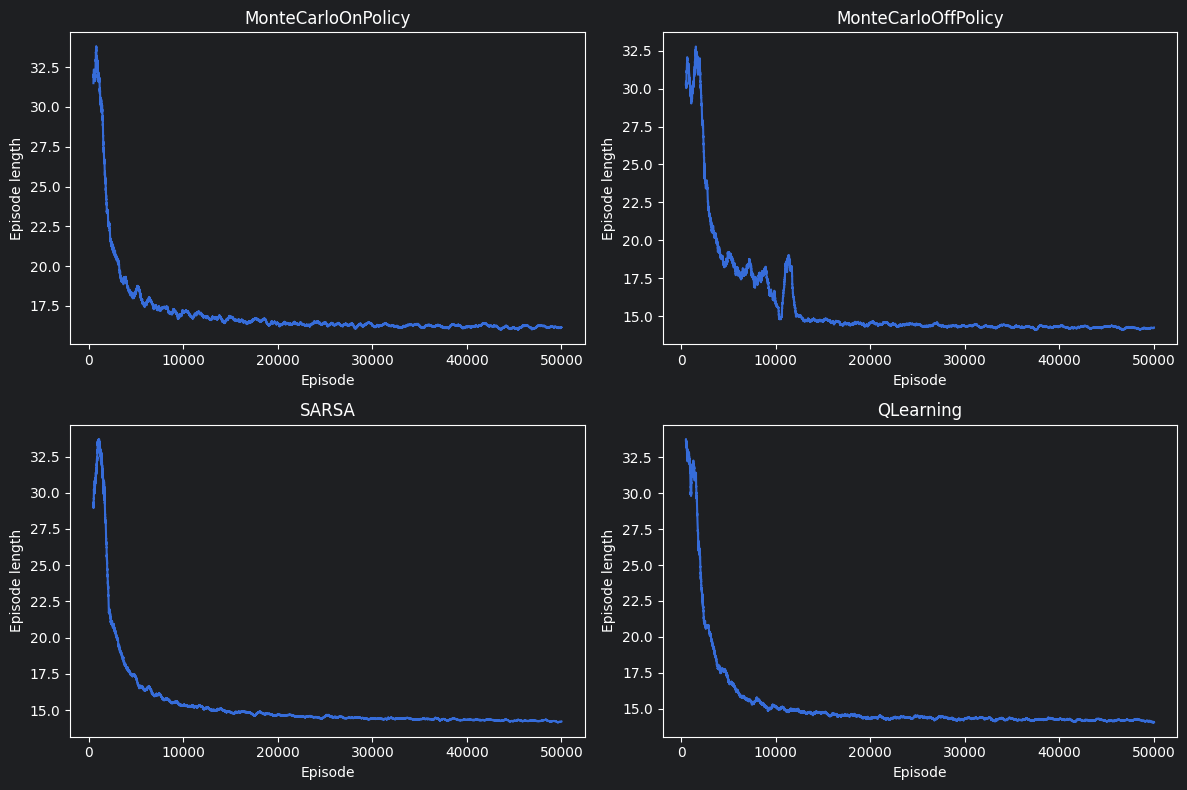

In [53]:
key = (1.0, 0.9)
plot_agent_rewards(results_stats[key])
plot_episode_lengths_for_agents(results_episode_lengths[key])

Mostramos la tabla Q para MonteCarlo On-Policy, y vemos, igual que en el caso anterior, que los retornos llevan al objetivo. Vemos como son significativamente menores que en el caso anterior, y esto es debido a que, solo la casilla objetivo vale 1, y al final este retorno se "reparte" hacia el origen del agente. Cuanto más grande es el mapa, menor será el retorno en las primeras casillas, en este caso.

Vemos como se dictan las acciones:
`LEFT, DOWN, RIGHT, UP = 0,1,2,3`

```
[0,0] --> acción 1 (derecha)
[0,1] --> acción 1 (abajo)
[1,1] --> acción 2 (derecha)
[1,2] --> acción 2 (derecha)
...
Hasta llegar al objetivo
```

In [54]:
key = (1.0, 0.9)
monte_carlo_on_policy_q = results_q_tables[key]['MonteCarloOnPolicy']
print(monte_carlo_on_policy_q)

[[4.34499742e-02 4.48451354e-02 1.66519137e-01 3.96420963e-02]
 [5.57573183e-02 1.88143328e-01 8.63247343e-02 6.24779932e-02]
 [1.52594232e-02 1.68717822e-02 1.65489139e-01 2.34444305e-02]
 [1.25965674e-01 1.24262426e-01 3.01086910e-01 1.45140919e-01]
 [1.59802692e-01 3.39112698e-01 1.99902588e-01 1.75355428e-01]
 [4.55359412e-02 6.83076123e-02 2.84577977e-01 5.77516374e-02]
 [8.33918963e-02 3.27174039e-01 8.63296472e-02 8.58681022e-02]
 [1.53099033e-02 1.15207308e-01 2.16559765e-02 1.63148896e-02]
 [6.27284664e-03 5.78256963e-03 9.01407987e-02 6.61014442e-03]
 [6.54891037e-02 6.69335025e-02 2.12042481e-01 6.95633840e-02]
 [9.35910135e-02 9.30575364e-02 2.38538926e-01 1.11185796e-01]
 [1.27845953e-01 0.00000000e+00 1.92124094e-01 2.71553471e-01]
 [1.54898746e-01 2.34187136e-01 3.81538907e-01 2.02377071e-01]
 [2.29444893e-01 4.28260357e-01 2.99177726e-01 2.47155811e-01]
 [1.04787893e-01 4.05445901e-01 1.46968480e-01 1.23718216e-01]
 [5.28682945e-02 2.40666825e-01 4.73846420e-02 4.188060

Imprimimos también la tabla de la política objetivo (pi estrella), en base a la tabla Q y al entorno. Se puede ver como la política se fija en consonancia con la tabla Q que hemos mostrado. Para cada estado, se contempla una única acción a realizar de las que hemos mencionado.


In [56]:
print_pi_star_from_q(env8, monte_carlo_on_policy_q)


Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 3.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 Acciones 2,

## **4. Análisis y Estudios Futuros**

En este estudio se ha podido comprobar como los distintos tipos de agentes que utilizan aprendizaje por refuerzo han resultado ser efectivos para la resolución del entorno de Frozen Lake. A continuación, exponemos una serie de puntos que consiguen englobar lo visto y comentado en apartados anteriores.

### **4.1 Análisis de Resultados**

- La búsqueda de hiperparámetros ha resultado ser efectiva para optimizar el funcionamiento de los agentes:
  - Un factor de descuento de 0.9 del retorno futuro ha resultado dar mejores resultados que tenerlo plenamente en cuenta (utilizando un valor de 1.0).
  - En caso de utilizar epsilon fijo durante todo el entrenamiento, ha dado mejor resultado utilizar un valor comedido, como 0.3, que valores más grandes, como 0.5. Los agentes se vuelven demasiado aleatorios.

- El uso de epsilon-decay, y que, por tanto, el agente presente al principio un comportamiento más exploratorio, y al final de la ejecución un comportamiento más greedy, explotando la política que ha aprendido, resulta dar también resultados más ventajosos que utilizar un valor fijo para epsilon.

- La evaluación en un entorno de mayores dimensiones y complejidad, como el de 8x8, dificulta el entrenamiento de los agentes. Son menos susceptibles a encontrar una solución (y por tanto, llegar a aprender una política y mucho menos óptima), e incrementa también el tiempo de cómputo del algoritmo.

- Por lo general, todos los tipos de agentes han presentado resultados deseables. Sin embargo, Monte Carlo On-Policy ha demostrado ser consistente a la hora de encontrar soluciones en más ocasiones y en menos tiempo que su variante Off-Policy y los otros agentes que emplean diferencias temporales, al menos para este problema concreto. Monte-Carlo Off-Policy se ha mostrado más sensible a utilizar un valor fijo para epsilon, que ha dado peores resultados que utilizando un epsilon decaimiento.


### **4.2 Propuestas para Estudios Futuros**

- Se podría ampliar la experimentación probando también con valores más grandes para el número de episodios.

- Sería interesante probar con diferentes valores para el `learning rate` para SARSA y Q-Learning en el grid de parámetros para ver si mejoran su desempeño con respecto, por ejemplo, a Monte Carlo.

- Adicionalmente, supondría un reto para los agentes utilizar la opción de `slipery = True`, que introduce un comportamiento estocástico al entorno para ver que agente es capaz de adaptarse mejor a esta dificultad añadida.

- Dado que existe la opción de configurar mapas para el Frozen Lake, sería también interesante entrenar a los agentes en uno customizado.

- Sería también muy interesante, de alguna forma, modificar el entorno para implementar recompensas negativas en los agujeros, y ver de qué forma repercute esto en el aprendizaje de los agentes.